# Deploy at the edge: conversion, budgets and device checks

CPU companion; no accelerator is required. TPU execution not validated.

- Trace source model through conversion, runtime and device execution.
- Measure a complete batch-one request separately from first-call overhead.
- Define calibration, held-out quality and device acceptance checks.
- Identify fallback operators and memory costs before claiming edge readiness.

A model works on your computer, and now you want it to run near the user—perhaps on a phone or an embedded board. Let’s trace the whole request, from raw input to usable output. We’ll check conversion, measure a batch-one CPU request, and write down what still needs to be measured on the real device.

## The idea

An edge deployment includes input decoding, preprocessing, transfers, inference and output handling under device constraints. Choose a target and an explicit request contract before claiming that an exported model is ready for that device.

## Measure the device path the user actually experiences

A converted operator may run on the intended accelerator while another falls back to the CPU. The end-to-end request can then pay transfer and scheduling costs absent from an isolated kernel measurement. Inspect actual runtime placement and supported operators.

Memory also has several parts: weights, activations, temporary workspace and runtime overhead. A smaller weight file does not guarantee the whole request fits the device's working-memory budget.

The CPU request trace is a useful reference for the interface. It cannot establish phone, browser, NPU or TPU performance. Repeat the same correctness cases on the named target, then measure cold and warm behavior with its runtime and power/thermal conditions recorded when relevant.

### Model speed is one part of request speed

**Predict:** If inference becomes twice as fast, does the whole request become twice as fast?

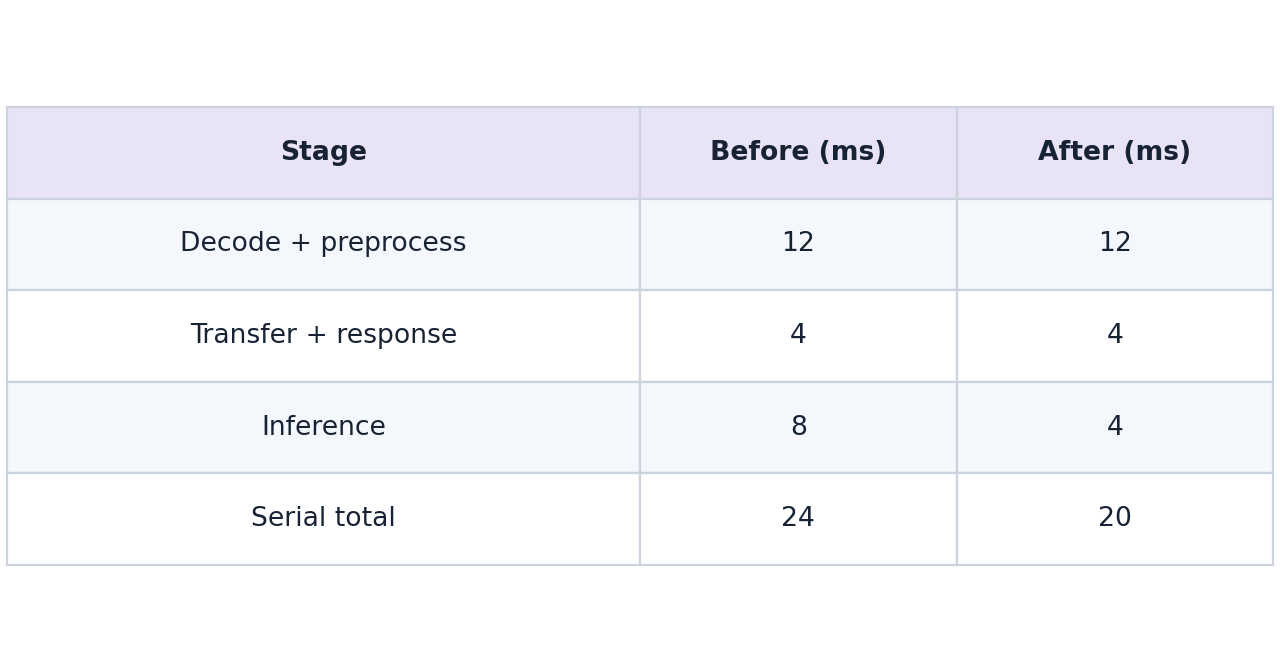

*Conceptual / analytic teaching diagram; not a recorded benchmark.*

Read the two columns as a hypothetical serial request before and after halving only inference. Preprocessing and transfer/response work remain unchanged. Add down each column: the total moves from $24$ to $20$ milliseconds, a $1.2$-fold improvement. These times are analytic teaching values; the separate plot contains actual local CPU request measurements.

### Pause and reason

What should you verify after conversion before interpreting a faster timing?

<details><summary>Compare your reasoning</summary>

Verify output behavior on the same inputs, operator placement/fallbacks and the complete request boundary. A faster but different computation is not a qualified optimization.

</details>

## Choose a deployment lane

For a phone or Linux edge device, LiteRT is one runtime option; ONNX Runtime offers execution providers for supported targets. Apple deployments may use Core ML after a supported conversion; PyTorch models may use ExecuTorch. Microcontrollers require a runtime and operator set designed for constrained memory, such as LiteRT for Microcontrollers. These are alternatives, not interchangeable file formats. Write down OS, device model, runtime version, operators, input shapes, precision policy and accelerator path before converting.

## Follow one concrete TensorFlow-to-LiteRT route

The optional labs/tensorflow_litert.py companion builds the known dense model in TensorFlow, converts float32 and fully integer variants, inspects input/output scale and zero point, quantizes requests and dequantizes outputs, then checks held-out predictions. Representative calibration inputs are preprocessed floats in the exact source-model input domain. Setting integer-only supported ops and int8 input/output requests a strict integer graph; unsupported conversion should fail rather than silently satisfy the contract with float fallback. The lab uses TensorFlow’s interpreter interface as a desktop compatibility check; it is not a device delegate test. Desktop conversion was verified with Python 3.12.13, TensorFlow 2.21.0 and Keras 3.15.1 on macOS arm64. The optional requirements file pins these tested top-level dependencies; other platforms still need a compatible installation.

**Optional TensorFlow environment — macOS/Linux, from the workspace root**

```sh
# Run optional tensorflow environment — macos/linux, from the workspace root using the course Python environment
python3.12 -m venv .venv-tensorflow
.venv-tensorflow/bin/python -m pip install -r phases/15-deployment/06-edge-ai-conversion-and-device-validation/labs/requirements-tensorflow.txt
.venv-tensorflow/bin/python phases/15-deployment/06-edge-ai-conversion-and-device-validation/labs/tensorflow_litert.py --output edge-artifacts
.venv-tensorflow/bin/python -m pip freeze > edge-artifacts/requirements-tested.txt
```

**Expected:** A compatible TensorFlow installation writes two .tflite files and report.json after numerical checks. Desktop float32 and INT8 conversion passed separately from the core CPU receipt; device validation remains unperformed. On Windows use .venv-tensorflow\Scripts\python.exe in place of .venv-tensorflow/bin/python. If no compatible TensorFlow wheel exists, choose a supported Python/platform combination from the official installation guide.

## Keep preprocessing attached to the model

Our sample uses three sensor features in the range $0$ to $255$ and divides by $255$ before inference. The JSON request exercises that boundary. A camera model also needs color order, resize/crop behavior and normalization; tokenizer-based models need vocabulary, special tokens and sequence rules. Keep preprocessing versioned with weights and output labels. Run the same raw golden inputs through the source pipeline and the device pipeline.

## Budget more than weights

Peak memory includes activations, tensors held by the runtime, workspace, preprocessing buffers and, for autoregressive models, KV cache. A compressed file may expand on load. Batch one often minimizes interaction latency but may reduce throughput. Include cold process startup, model load and runtime initialization in a separate device cold-start measurement; our first-request timing starts after imports and model setup, so it does not cover them. Measure power or energy with an actual target-device tool and record thermal state.

## Measure the request the user experiences

The timer includes JSON decoding, normalization, host/device placement, inference completion and response encoding. Thirty warm requests produce an instructional p50 and p95, not a production tail-latency estimate. A device report needs more samples, realistic input variation and sustained runs to reveal thermal throttling. Never reuse a kernel-only time as end-to-end latency. Verify the numerical output before interpreting any timings.

## Device acceptance is an experiment

Choose quality, memory, startup and latency thresholds before comparing candidates. Record runtime/delegate logs and partitioning so unsupported operators cannot quietly fall back to CPU. Compare float32, FP16 and calibrated INT8 where that device supports them. Retain the original artifact, hashes, versions, input/output metadata, calibration provenance and failed cases. A conversion failure, regression on rare inputs or memory-budget failure is a result to diagnose. Leave device fields unmeasured until tested on the named hardware.

## Declare the raw sensor contract before normalizing

This exercise uses one row of three numeric sensor values in the range $[0,255]$. Numeric strings, booleans, missing values, extra fields and out-of-range readings are rejected. That is a deliberately chosen protocol for this fixture, not a rule for every sensor. If a physical device uses a different unit or range, change and version the contract before changing the model.

Check the raw values before converting them to an array. Otherwise a convenient cast may turn a string or boolean into a plausible number, hiding a caller's mistake. After validation, divide by $255$ exactly once. Keep that conversion with the model release so the desktop reference and device application see the same numeric inputs.

## Spend a latency budget across the whole request

Suppose decoding and preprocessing take $12$ milliseconds, transfers and response handling take $4$, and inference takes $8$. The request takes $24$ milliseconds if these stages run serially. Halving inference time reduces the total to $20$, not $12$. The model sped up by a factor of two; the request sped up by only $24/20=1.2$.

These are illustrative stage times, not observations from the course device. On a real target, instrument the same request boundary, check whether stages overlap, and record warmup, temperature, power mode and operator fallback. If transfers dominate, a smaller model may help less than reducing transfers. Compare those hypotheses with traces before choosing an intervention.

$$
\mathrm{speedup}=\frac{t_{\mathrm{other}}+t_{\mathrm{model}}}{t_{\mathrm{other}}+t_{\mathrm{model}}/s}
$$

## Keep a known inference function

Create main.py in your lesson workspace and run it with the active course Python environment. Define the fixed dense model and check the parameter shapes without invoking the compiled function.

In [1]:
# Step 1 — Keep a known inference function: A row has three sensor features and the result has two scores.
# Import json for this computation.
import json
import time
import numpy as np
import jax
import jax.numpy as jnp
# Initialize array `weights` with explicit values and shape.
weights = jnp.array([[1., -2.], [.5, 1.], [-1., .25]], jnp.float32)
# Initialize array `bias` with explicit values and shape.
bias = jnp.array([.1, -.2], jnp.float32)
# Define and JIT-compile `infer(features)` so XLA traces and fuses the operations:
@jax.jit
# Function `infer(features)` implementing this stage's computation:
def infer(features):
    # Return `features @ weights + bias` to the caller.
    return features @ weights + bias

# Verify that the output tensor shape matches our prediction.
assert weights.shape == (3, 2) and bias.shape == (2,)

A row has three sensor features and the result has two scores. Leave the compiled function uncalled so the later first-request measurement can include initialization.

## Build the raw-request boundary

Append this block to the same main.py and rerun the whole file. Validate the raw JSON protocol, normalize once, wait for inference, and encode the result.

In [2]:
# Step 2 — Build the raw-request boundary: This probe checks decoding and raw values without running inference.
payload = json.dumps({"features": [[255., 128., 0.]]})
# Function `validate_sensor_payload(payload)` implementing this stage's computation:
def validate_sensor_payload(payload):
    # Read or serialize artifact data on disk (`document`).
    document = json.loads(payload)
    # Guard input contract (`not isinstance(document, dict) or set(document) != {'features'}`) and fail fast if violated.
    if not isinstance(document, dict) or set(document) != {'features'}:
        raise ValueError('expected features object')
    # Evaluate `rows` from the current inputs and state.
    rows = document['features']
    # Guard input contract (`not isinstance(rows, list) or len(rows) != 1 or (not isinstance(rows[0], list)) or (len(rows[0]) != 3)`) and fail fast if violated.
    if not isinstance(rows, list) or len(rows) != 1 or not isinstance(rows[0], list) or len(rows[0]) != 3:
        raise ValueError('expected one row of three sensor values')
    # Guard input contract (`any((type(value) not in (int, float) or not 0 <= value <= 255 or (not np.isfinite(value)) for value in rows[0]))`) and fail fast if violated.
    if any(type(value) not in (int, float) or not 0 <= value <= 255 or not np.isfinite(value) for value in rows[0]):
        raise ValueError('expected numeric sensor values in the range 0 through 255')
    # Return `np.asarray(rows, dtype=np.float32)` to the caller.
    return np.asarray(rows, dtype=np.float32)
# Function `request(payload)` implementing this stage's computation:
def request(payload):
    # Run `validate_sensor_payload` to compute `decoded`.
    decoded = validate_sensor_payload(payload)
    # Evaluate `features` from the current inputs and state.
    features = decoded / 255.
    # Synchronize host execution until asynchronous device computation completes.
    output = np.asarray(infer(jnp.asarray(features)).block_until_ready())
    # Return `json.dumps({'scores': output.tolist()})` to the caller.
    return json.dumps({"scores": output.tolist()})

# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_array_equal(validate_sensor_payload(payload), [[255., 128., 0.]])

This probe checks decoding and raw values without running inference. Keep normalization inside request so it happens exactly once.

## Measure cold and warm requests separately

Append this block to the same main.py and rerun the whole file. Time the first request, then retain every warm observation.

In [3]:
# Step 3 — Measure cold and warm requests separately: The first request can include compilation and initialization.
start = time.perf_counter()
# Run `request` to compute `first_response`.
first_response = request(payload)
# Record execution timing or profiler trace in `first_ms`.
first_ms = (time.perf_counter() - start) * 1000
# Evaluate `samples` from the current inputs and state.
samples = []
# Repeat the update loop over `range(30)` steps:
for _ in range(30):
    # Record execution timing or profiler trace in `start`.
    start = time.perf_counter()
    # Run `request` to compute `response`.
    response = request(payload)
    # Record execution timing or profiler trace in ``.
    samples.append((time.perf_counter() - start) * 1000)

The first request can include compilation and initialization. The line plot contains only the subsequent warm requests; do not describe its first point as the cold request.

## Validate outputs and describe measurement scope

Append this block to the same main.py and rerun the whole file. Compare the response with independent NumPy arithmetic and write an honest measurement report.

In [4]:
# Step 4 — Validate outputs and describe measurement scope: The report records local CPU timings and explicitly leaves...
# Initialize array `expected` with explicit values and shape.
expected = (np.array([[255., 128., 0.]], np.float32) / 255.) @ np.asarray(weights) + np.asarray(bias)
# Read or serialize artifact data on disk (``).
np.testing.assert_allclose(json.loads(response)["scores"], expected, atol=1e-6)
# Evaluate `report` from the current inputs and state.
report = {"runtime": "JAX CPU instructional proxy", "jax": jax.__version__,
          "first_request_ms": first_ms, "warm_samples_ms": samples,
          "p50_ms": float(np.percentile(samples, 50)), "p95_ms": float(np.percentile(samples, 95)),
          "boundary": "JSON decode + normalize + transfer + infer + wait + encode",
          "edge_device_validated": False}
# Verify contract: `len(samples) == 30 and all((t >= 0 for t in samples))`.
assert len(samples) == 30 and all(t >= 0 for t in samples)
# Print the observed values to compare against the expected result.
print(json.dumps(report, indent=2))

# Convert `` to a host NumPy array for inspection or verification.
np.testing.assert_allclose(json.loads(request(json.dumps({'features':[[0,0,0]]})))['scores'], np.asarray(bias)[None,:], atol=1e-6)

{
  "runtime": "JAX CPU instructional proxy",
  "jax": "0.9.2",
  "first_request_ms": 14.632124919444323,
  "warm_samples_ms": [
    0.16558310016989708,
    0.07675029337406158,
    0.05837529897689819,
    0.0539594329893589,
    0.04950026050209999,
    0.04879198968410492,
    0.045000109821558,
    0.0449158251285553,
    0.047791749238967896,
    0.044084154069423676,
    0.0427919439971447,
    0.04100007936358452,
    0.040708109736442566,
    0.04020892083644867,
    0.03974977880716324,
    0.039041973650455475,
    0.039709266275167465,
    0.04062522202730179,
    0.03954209387302399,
    0.03933301195502281,
    0.0389590859413147,
    0.03900006413459778,
    0.03949971869587898,
    0.04016561433672905,
    0.03875000402331352,
    0.039458274841308594,
    0.038458965718746185,
    0.03854092210531235,
    0.038708094507455826,
    0.03808317705988884
  ],
  "p50_ms": 0.04018726758658886,
  "p95_ms": 0.068481545895338,
  "boundary": "JSON decode + normalize + transfer +

The report records local CPU timings and explicitly leaves edge-device qualification false. Carry the same protocol to a named device before replacing that field.

## Run the example

In [5]:
# Deploy at the edge: conversion, budgets and device checks: An edge deployment includes input decoding, preprocessing,...
# Import json for this computation.
import json
import time
import numpy as np
import jax
import jax.numpy as jnp
# Initialize array `weights` with explicit values and shape.
weights = jnp.array([[1., -2.], [.5, 1.], [-1., .25]], jnp.float32)
# Initialize array `bias` with explicit values and shape.
bias = jnp.array([.1, -.2], jnp.float32)
# Define and JIT-compile `infer(features)` so XLA traces and fuses the operations:
@jax.jit
# Function `infer(features)` implementing this stage's computation:
def infer(features):
    # Return `features @ weights + bias` to the caller.
    return features @ weights + bias
# Read or serialize artifact data on disk (`payload`).
payload = json.dumps({"features": [[255., 128., 0.]]})
# Function `validate_sensor_payload(payload)` implementing this stage's computation:
def validate_sensor_payload(payload):
    # Read or serialize artifact data on disk (`document`).
    document = json.loads(payload)
    # Guard input contract (`not isinstance(document, dict) or set(document) != {'features'}`) and fail fast if violated.
    if not isinstance(document, dict) or set(document) != {'features'}:
        raise ValueError('expected features object')
    # Evaluate `rows` from the current inputs and state.
    rows = document['features']
    # Guard input contract (`not isinstance(rows, list) or len(rows) != 1 or (not isinstance(rows[0], list)) or (len(rows[0]) != 3)`) and fail fast if violated.
    if not isinstance(rows, list) or len(rows) != 1 or not isinstance(rows[0], list) or len(rows[0]) != 3:
        raise ValueError('expected one row of three sensor values')
    # Guard input contract (`any((type(value) not in (int, float) or not 0 <= value <= 255 or (not np.isfinite(value)) for value in rows[0]))`) and fail fast if violated.
    if any(type(value) not in (int, float) or not 0 <= value <= 255 or not np.isfinite(value) for value in rows[0]):
        raise ValueError('expected numeric sensor values in the range 0 through 255')
    # Return `np.asarray(rows, dtype=np.float32)` to the caller.
    return np.asarray(rows, dtype=np.float32)
# Function `request(payload)` implementing this stage's computation:
def request(payload):
    # Run `validate_sensor_payload` to compute `decoded`.
    decoded = validate_sensor_payload(payload)
    # Evaluate `features` from the current inputs and state.
    features = decoded / 255.
    # Synchronize host execution until asynchronous device computation completes.
    output = np.asarray(infer(jnp.asarray(features)).block_until_ready())
    # Return `json.dumps({'scores': output.tolist()})` to the caller.
    return json.dumps({"scores": output.tolist()})
# Record execution timing or profiler trace in `start`.
start = time.perf_counter()
# Run `request` to compute `first_response`.
first_response = request(payload)
# Record execution timing or profiler trace in `first_ms`.
first_ms = (time.perf_counter() - start) * 1000
# Evaluate `samples` from the current inputs and state.
samples = []
# Repeat the update loop over `range(30)` steps:
for _ in range(30):
    # Record execution timing or profiler trace in `start`.
    start = time.perf_counter()
    # Run `request` to compute `response`.
    response = request(payload)
    # Record execution timing or profiler trace in ``.
    samples.append((time.perf_counter() - start) * 1000)
# Convert `expected` to a host NumPy array for inspection or verification.
expected = (np.array([[255., 128., 0.]], np.float32) / 255.) @ np.asarray(weights) + np.asarray(bias)
# Read or serialize artifact data on disk (``).
np.testing.assert_allclose(json.loads(response)["scores"], expected, atol=1e-6)
# Evaluate `report` from the current inputs and state.
report = {"runtime": "JAX CPU instructional proxy", "jax": jax.__version__,
          "first_request_ms": first_ms, "warm_samples_ms": samples,
          "p50_ms": float(np.percentile(samples, 50)), "p95_ms": float(np.percentile(samples, 95)),
          "boundary": "JSON decode + normalize + transfer + infer + wait + encode",
          "edge_device_validated": False}
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert len(samples) == 30 and all(t >= 0 for t in samples)
# Print diagnostic summary of the computed outputs.
print(json.dumps(report, indent=2))

{
  "runtime": "JAX CPU instructional proxy",
  "jax": "0.9.2",
  "first_request_ms": 11.602125130593777,
  "warm_samples_ms": [
    0.13008294627070427,
    0.06433296948671341,
    0.053209252655506134,
    0.04854192957282066,
    0.04741735756397247,
    0.044374726712703705,
    0.04191696643829346,
    0.04754215478897095,
    0.042415689677000046,
    0.042084138840436935,
    0.04154164344072342,
    0.041165854781866074,
    0.040374696254730225,
    0.04041614010930061,
    0.03987504169344902,
    0.04016561433672905,
    0.04133395850658417,
    0.03974977880716324,
    0.039332546293735504,
    0.0394587405025959,
    0.04091579467058182,
    0.03995886072516441,
    0.039832666516304016,
    0.03862520679831505,
    0.04054233431816101,
    0.03954116255044937,
    0.0394163653254509,
    0.03912486135959625,
    0.03929203376173973,
    0.038458965718746185
  ],
  "p50_ms": 0.04047923721373081,
  "p95_ms": 0.05932729691267011,
  "boundary": "JSON decode + normalize + tra

Expected: A JSON report with $30$ measured warm requests, first-request time, p50/p95 and `edge_device_validated=false`. Timings depend on this CPU; no device speedup is asserted.

## An end-to-end boundary includes more than inference

Predict: Which parts of a request are included in these samples?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [6]:
# Compute figure data for: An end-to-end boundary includes more than inference
# Evaluate `visual_data` from the current inputs and state.
visual_data = {'kind': 'line', 'x': list(range(1, len(samples) + 1)), 'xlabel': 'warm request number', 'ylabel': 'end-to-end milliseconds', 'series': [{'label': 'local CPU request', 'y': samples}, {'label': 'recorded p95', 'y': [report['p95_ms']] * len(samples)}]}

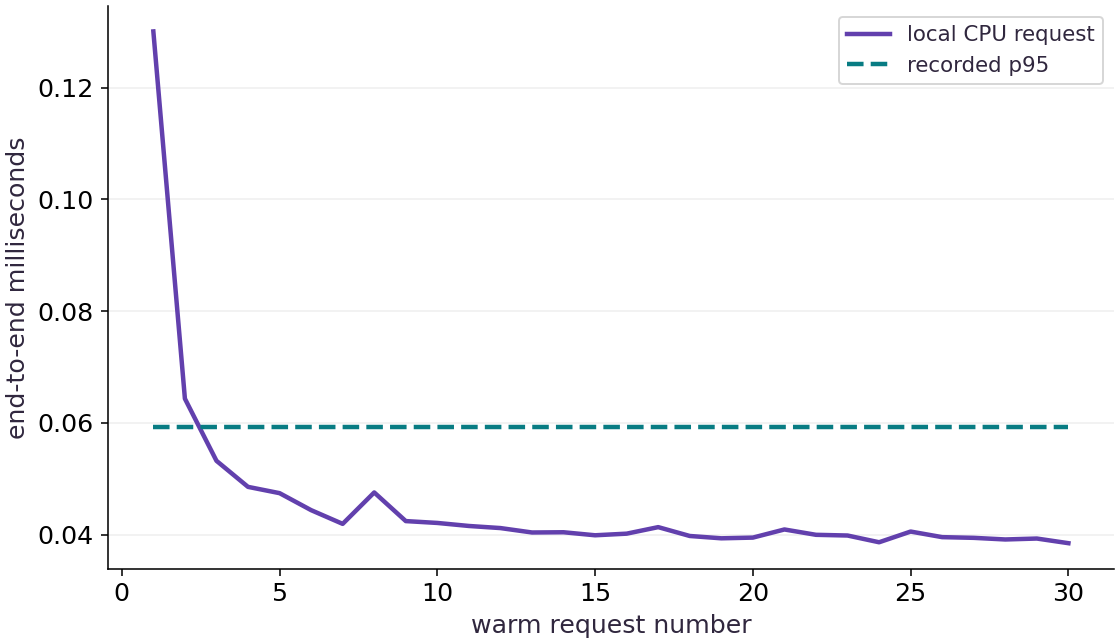

In [7]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The horizontal axis counts warm requests, and the vertical axis measures end-to-end latency in milliseconds. The solid line joins the measured request times. The dashed horizontal line is the empirical $95$th percentile of those same $30$ samples; it is a summary threshold, not a second implementation.

Read a solid point above the dashed line as a request slower than that percentile threshold. The line is not the maximum, so a few points can lie above it. The first cold request is reported separately and is not the first point of this warm-only plot.

### Connect it to the computation

Each duration includes JSON decoding, normalization, transfer, inference, waiting for completion, and encoding the response. That boundary explains why the chart should not be read as pure model execution time. An early high warm point or later spike shows variation in the whole request; this plot alone cannot identify its cause.

The percentile is computed from a small sample, with interpolation between ordered values. It does not guarantee that future requests will meet the threshold. Compare the sample distribution, median, and tail across repeated runs on the target device. These are local CPU proxy measurements, not evidence of mobile or edge-device latency.

## A normalization mismatch survives conversion

Predict: Will raw sensor values and normalized values produce the same scores?

In [8]:
# Experiment — A normalization mismatch survives conversion: Conversion checks must start at the raw input boundary when...
# Initialize array `raw` with explicit values and shape.
raw = np.array([[255., 128., 0.]], np.float32)
# Convert `wrong` to a host NumPy array for inspection or verification.
wrong = np.asarray(infer(raw))
# Convert `right` to a host NumPy array for inspection or verification.
right = np.asarray(infer(raw / 255.))
# Verify that the numerical values match the expected reference within tolerance.
assert not np.allclose(wrong, right)
# Print the observed values to compare against the expected result.
print("Preprocessing mismatch max error", float(np.max(np.abs(wrong-right))))

Preprocessing mismatch max error 380.5019836425781


Expected: The mismatch is large despite identical weights.

Conversion checks must start at the raw input boundary when preprocessing is part of the product.

## Reject raw inputs before normalization hides their meaning

Predict: Would an array cast distinguish a numeric string, a boolean and a legitimate sensor reading?

In [9]:
# Experiment — Reject raw inputs before normalization hides their meaning: The zero-input oracle checks that preprocessing does not add a...
invalid_payloads=[{'features':[['255',128,0]]},{'features':[[True,128,0]]},{'features':[[256,128,0]]},{'features':[[-1,128,0]]},{'features':[[0,1]]},{'features':[[0,1,float('nan')]]},{'features':[[0,1,2]],'extra':1}]
# Iterate over `invalid` to step through the computation:
for invalid in invalid_payloads:
    try: request(json.dumps(invalid))
    except ValueError: pass
    else: raise AssertionError('invalid sensor payload accepted')
# Convert `` to a host NumPy array for inspection or verification.
np.testing.assert_allclose(json.loads(request(json.dumps({'features':[[0,0,0]]})))['scores'],np.asarray(bias)[None,:],atol=1e-6)
# Print the observed values to compare against the expected result.
print('Seven malformed or out-of-domain requests rejected; zero input returns the bias.')

Seven malformed or out-of-domain requests rejected; zero input returns the bias.


Expected: All seven invalid payloads fail. A valid zero-valued row produces the two bias scores.

The zero-input oracle checks that preprocessing does not add a hidden offset. Rejection tests check input meaning before the model sees an apparently valid float array.

## Your exercise

Send a second raw input $[0, 255, 128]$ through the full request, and verify its independent normalized NumPy result.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.

**Step-by-step implementation plan:**
1. Initialize array `changed_raw` with explicit values and shape.
2. Read or serialize artifact data on disk (`changed_response`).
3. Convert `expected_changed` to a host NumPy array for inspection or verification.
4. Verify that computed values match the expected reference within numerical tolerance.
5. Print the observed values to compare against the expected result.

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Send a second raw input [0, 255, 128] through the full request, and...
# Initialize array `changed_raw` with explicit values and shape.
changed_raw = np.array(...)  # TODO: compute changed_raw
# Read or serialize artifact data on disk (`changed_response`).
changed_response = json.loads(...)  # TODO: compute changed_response
# Convert `expected_changed` to a host NumPy array for inspection or verification.
expected_changed = ...  # TODO: compute expected_changed
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(changed_response["scores"], expected_changed, atol = ...  # TODO: compute np.testing.assert_allclose(changed_response["scores"], expected_changed, atol
# Print the observed values to compare against the expected result.
print("Changed end-to-end request verified")
```

In [10]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Send a second raw input [0, 255, 128] through the full request, and...
# Initialize array `changed_raw` with explicit values and shape.
# changed_raw = np.array(...)  # TODO: compute changed_raw
# Read or serialize artifact data on disk (`changed_response`).
# changed_response = json.loads(...)  # TODO: compute changed_response
# Convert `expected_changed` to a host NumPy array for inspection or verification.
# expected_changed = ...  # TODO: compute expected_changed
# Verify that computed values match the expected reference within numerical tolerance.
# np.testing.assert_allclose(changed_response["scores"], expected_changed, atol = ...  # TODO: compute np.testing.assert_allclose(changed_response["scores"], expected_changed, atol
# Print the observed values to compare against the expected result.
# print("Changed end-to-end request verified")

## Reference solution

Try your own implementation first.

In [11]:
# Exercise solution: Send a second raw input [0, 255, 128] through the full request, and...
# Initialize array `changed_raw` with explicit values and shape.
changed_raw = np.array([[0., 255., 128.]], np.float32)
# Read or serialize artifact data on disk (`changed_response`).
changed_response = json.loads(request(json.dumps({"features": changed_raw.tolist()})))
# Convert `expected_changed` to a host NumPy array for inspection or verification.
expected_changed = (changed_raw / 255.) @ np.asarray(weights) + np.asarray(bias)
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(changed_response["scores"], expected_changed, atol=1e-6)
# Print the observed values to compare against the expected result.
print("Changed end-to-end request verified")

Changed end-to-end request verified


## Make incomplete deployment evidence explicit · Transfer

Create a device report template with required hardware and measurement fields. Reject it as ready while those fields are missing.

Hint: List the hardware, runtime, delegate and measurement fields before testing completeness. A missing value is different from a measured zero or an explicitly unsupported capability.

### How to write: Make incomplete deployment evidence explicit — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `explicit(...)` — Call `explicit` with your updated parameters or inputs from this lesson's workspace.
- `device_report.items(...)` — Call `device_report.items` with your updated parameters or inputs from this lesson's workspace.
- `assert condition` — Verify that the observed output shape, status, or numerical value satisfies the contract.

**Step-by-step implementation plan:**
1. Evaluate `missing` from the current inputs and state.
2. Verify contract: `missing and 'device' in missing`.
3. Print the observed values to compare against the expected result.

**Starter code scaffold (fill in the TODOs):**

```python
# Make incomplete deployment evidence explicit (Transfer): Empty evidence stays empty.
device_report = ...  # TODO: compute device_report
                 "quality_metric": None, "p95_ms": None, "peak_memory_bytes": None,
                 "cold_start_ms": None, "fallback_operators": None}
# Evaluate `missing` from the current inputs and state.
missing = ...  # TODO: compute missing
# Verify contract: `missing and 'device' in missing`.
assert missing  # TODO: complete assertion check
# Print the observed values to compare against the expected result.
print("Not device-validated; missing:", ", ".join(missing))
```

In [12]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Make incomplete deployment evidence explicit (Transfer): Empty evidence stays empty.
# device_report = ...  # TODO: compute device_report
#                  "quality_metric": None, "p95_ms": None, "peak_memory_bytes": None,
#                  "cold_start_ms": None, "fallback_operators": None}
# Evaluate `missing` from the current inputs and state.
# missing = ...  # TODO: compute missing
# Verify contract: `missing and 'device' in missing`.
# assert missing  # TODO: complete assertion check
# Print the observed values to compare against the expected result.
# print("Not device-validated; missing:", ", ".join(missing))

## Reference reasoning

Empty evidence stays empty. Desktop conversion and simulation cannot populate measurements for hardware that was never used.

In [13]:
# Make incomplete deployment evidence explicit (Transfer): Empty evidence stays empty.
device_report = {"device": None, "runtime_version": None, "delegate": None,
                 "quality_metric": None, "p95_ms": None, "peak_memory_bytes": None,
                 "cold_start_ms": None, "fallback_operators": None}
# Evaluate `missing` from the current inputs and state.
missing = [key for key, value in device_report.items() if value is None]
# Verify contract: `missing and 'device' in missing`.
assert missing and "device" in missing
# Print the observed values to compare against the expected result.
print("Not device-validated; missing:", ", ".join(missing))

Not device-validated; missing: device, runtime_version, delegate, quality_metric, p95_ms, peak_memory_bytes, cold_start_ms, fallback_operators


## Decide whether a model speedup meets the request budget · Transfer / diagnosis

Use the illustrative serial times above. A $19$-millisecond deadline is declared before optimization. Does halving model time meet it? What is the best possible total if model time tends to zero?

Hint: Keep the fixed work unchanged. Compare the total request with the deadline, not the model-only duration.

### How to write: Decide whether a model speedup meets the request budget — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.

**Step-by-step implementation plan:**
1. Evaluate `before_ms` from the current inputs and state.
2. Evaluate `after_ms` from the current inputs and state.
3. Verify that computed values match the expected reference within numerical tolerance.
4. Verify contract: `after_ms > deadline_ms and fixed_ms == 16.0`.
5. Print the observed values to compare against the expected result.

**Starter code scaffold (fill in the TODOs):**

```python
# Decide whether a model speedup meets the request budget (Transfer / diagnosis): Halving model time leaves a 20-millisecond request, so it...
fixed_ms = ...  # TODO: compute fixed_ms
# Evaluate `before_ms` from the current inputs and state.
before_ms = ...  # TODO: compute before_ms
# Evaluate `after_ms` from the current inputs and state.
after_ms = ...  # TODO: compute after_ms
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose([before_ms,after_ms,before_ms/after_ms],[24.,20.,1.2])
# Verify contract: `after_ms > deadline_ms and fixed_ms == 16.0`.
assert after_ms  # TODO: complete assertion check
# Print the observed values to compare against the expected result.
print('Illustrative request before/after/lower-bound (ms):',before_ms,after_ms,fixed_ms)
```

In [14]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Decide whether a model speedup meets the request budget (Transfer / diagnosis): Halving model time leaves a 20-millisecond request, so it...
# fixed_ms = ...  # TODO: compute fixed_ms
# Evaluate `before_ms` from the current inputs and state.
# before_ms = ...  # TODO: compute before_ms
# Evaluate `after_ms` from the current inputs and state.
# after_ms = ...  # TODO: compute after_ms
# Verify that computed values match the expected reference within numerical tolerance.
# np.testing.assert_allclose([before_ms,after_ms,before_ms/after_ms],[24.,20.,1.2])
# Verify contract: `after_ms > deadline_ms and fixed_ms == 16.0`.
# assert after_ms  # TODO: complete assertion check
# Print the observed values to compare against the expected result.
# print('Illustrative request before/after/lower-bound (ms):',before_ms,after_ms,fixed_ms)

## Reference reasoning

Halving model time leaves a $20$-millisecond request, so it misses the stated deadline. The serial fixed work gives a $16$-millisecond lower bound even with zero model time. Replace these illustrative values with measurements before making a device decision.

In [15]:
# Decide whether a model speedup meets the request budget (Transfer / diagnosis): Halving model time leaves a 20-millisecond request, so it...
fixed_ms=12.+4.;model_ms=8.;deadline_ms=19.
# Evaluate `before_ms` from the current inputs and state.
before_ms=fixed_ms+model_ms
# Evaluate `after_ms` from the current inputs and state.
after_ms=fixed_ms+model_ms/2
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose([before_ms,after_ms,before_ms/after_ms],[24.,20.,1.2])
# Verify contract: `after_ms > deadline_ms and fixed_ms == 16.0`.
assert after_ms>deadline_ms and fixed_ms==16.
# Print the observed values to compare against the expected result.
print('Illustrative request before/after/lower-bound (ms):',before_ms,after_ms,fixed_ms)

Illustrative request before/after/lower-bound (ms): 24.0 20.0 16.0


## Checkpoint

A LiteRT file converts successfully. What must happen before claiming NPU latency?

1. Run it on the named device, verify execution placement and measure the stated request boundary.
2. Divide CPU latency by the weight compression ratio.
3. Assume every operator uses the NPU.

## Diagnose

If INT8 quality drops, compare float conversion first, then verify calibration preprocessing, ranges and quantization metadata. If device latency disappoints, inspect fallback partitions, copies, request preprocessing and thermal conditions. If startup dominates, report it separately from warm inference and test the actual loading strategy.

## Evidence

Keep the CPU request report, preprocessing equivalence checks, chosen runtime/operator/precision matrix and an unfilled target-device report until actual device measurements exist. For the optional converter, retain the artifact, quantization metadata and held-out comparison.

## Primary references

- [LiteRT integer conversion tutorial](https://developers.google.com/edge/litert/conversion/tensorflow/quantization/post_training_integer_quant)
- [LiteRT float16 conversion](https://developers.google.com/edge/litert/conversion/tensorflow/quantization/post_training_float16_quant)
- [ONNX Runtime quantization and providers](https://onnxruntime.ai/docs/performance/model-optimizations/quantization.html)
- [ExecuTorch edge runtime](https://docs.pytorch.org/executorch/stable/index.html)
- [Core ML Tools overview](https://apple.github.io/coremltools/docs-guides/source/overview-coremltools.html)
- [LiteRT for Microcontrollers](https://developers.google.com/edge/litert/microcontrollers/overview)
- [TensorFlow installation and supported platforms](https://www.tensorflow.org/install/pip)